# **Laboratorio 9, Física computacional 1**

Juan Esteban Garces Duran

C.C 1077225154

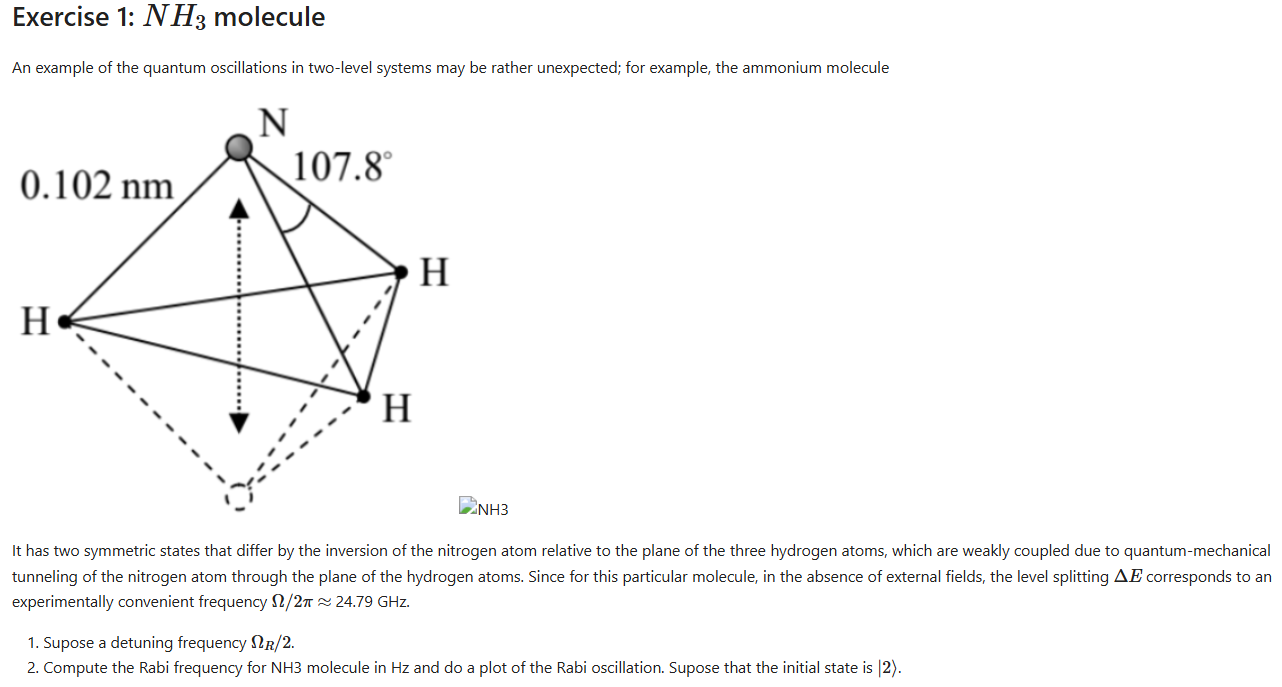

Para la molécula de amoníaco se tienen dos configuraciones posibles dependiendo de la posición de del átomo de hidrogeno. Un estado se da cuando el nitrogeno esta arriba del plano de los tres hidrogenos, y el otro es cuando se encuentra abajo.

De esta forma, definimos los estados

- $|1\rangle$: Nitrogeno **arriba**.
- $|2\rangle$: Nitrogeno **abajo**.


### Evolución temporal de las probabilidades

Se supone que el sistema se encuentra inicialmente en el estado

$$
|\psi(0)\rangle = |2\rangle =
\begin{pmatrix}
0\\
1
\end{pmatrix},
$$

lo que significa que la molécula comienza con el átomo de nitrógeno en la configuración correspondiente al estado $|2\rangle$.

La probabilidad de encontrar la molécula en el mismo estado después de un tiempo $t$ está dada por

$$
P_2(t)=\cos^2(\Omega t)+\left(\frac{\Delta}{\Omega}\right)^2\sin^2(\Omega t),
$$

donde $\Omega$ es la frecuencia angular generalizada y $\Delta$ representa el **detuning** o desintonización del sistema.

Por otra parte, la probabilidad de que la molécula haya transitado al estado $|1\rangle$ es

$$
P_1(t)=\left(\frac{\Omega_R}{\Omega}\right)^2\sin^2(\Omega t),
$$

donde $\Omega_R$ es la frecuencia angular de Rabi.

Estas probabilidades cumplen la condición de normalización

$$
P_1(t)+P_2(t)=1,
$$

lo que garantiza la conservación de la probabilidad durante la evolución temporal del sistema cuántico.

En este ejercicio se considera una desintonización dada por

$$
\Delta=\frac{\Omega_R}{2},
$$

por lo que las oscilaciones entre ambos estados no son completas. En consecuencia, la probabilidad de transición nunca alcanza el 100 %, sino que presenta una amplitud máxima determinada por la relación entre la frecuencia de Rabi y la frecuencia generalizada.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Frecuencia dada por el problema (Hz)
f = 24.79e9

# Frecuencia angular total
Omega = 2*np.pi*f

# El problema indica que Delta = Omega_R/2
Omega_R = Omega / np.sqrt(5/4)
Delta = Omega_R / 2

print(f"Omega = {Omega:.4e} rad/s")
print(f"Omega_R = {Omega_R:.4e} rad/s")
print(f"Frecuencia de Rabi = {Omega_R/(2*np.pi):.4e} Hz")
print(f"Frecuencia de Rabi = {Omega_R/(2*np.pi)/1e9:.2f} GHz")

Omega = 1.5576e+11 rad/s
Omega_R = 1.3932e+11 rad/s
Frecuencia de Rabi = 2.2173e+10 Hz
Frecuencia de Rabi = 22.17 GHz


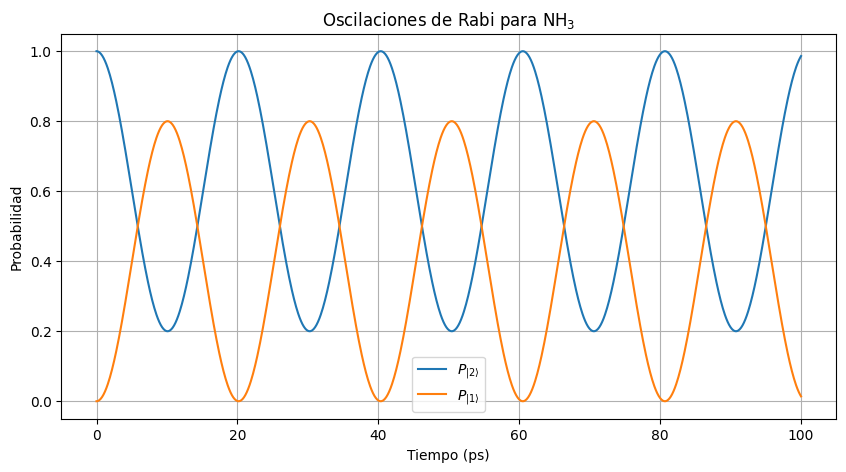

In [4]:
t = np.linspace(0,1e-10,1000)


# Probabilidades
P2 = np.cos(Omega*t)**2 + (Delta/Omega)**2*np.sin(Omega*t)**2
P1 = (Omega_R/Omega)**2*np.sin(Omega*t)**2


# Graficamos
plt.figure(figsize=(10,5))
plt.plot(t*1e12,P2,label=r'$P_{|2\rangle}$')
plt.plot(t*1e12,P1,label=r'$P_{|1\rangle}$')
plt.xlabel("Tiempo (ps)")
plt.ylabel("Probabilidad")
plt.title("Oscilaciones de Rabi para NH$_3$")
plt.grid(True)
plt.legend()
plt.show()

Como se consideró una desintonización dada por

$$
\Delta=\frac{\Omega_R}{2},
$$

la transferencia de probabilidad entre ambos estados no es completa, por lo que el sistema nunca alcanza una probabilidad del 100 % de encontrarse en el estado  $|1\rangle$. En la gráfica se observa que la probabilidad máxima de transición es del **80 %**, mientras que siempre permanece una fracción de la población en el estado inicial.

Además, las probabilidades satisfacen en todo instante la condición de normalización

$$
P_1(t)+P_2(t)=1,
$$

lo que confirma la conservación de la probabilidad durante la evolución temporal del sistema cuántico y demuestra el comportamiento coherente de las oscilaciones de Rabi en la molécula de amoníaco.

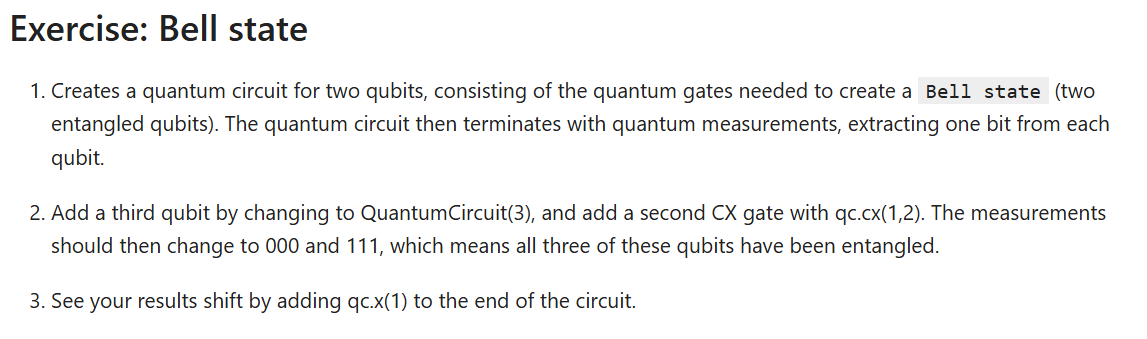

In [6]:
!pip install qiskit qiskit-aer pylatexenc
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=deb75cca9b30f2e577805a00988075df9ebf2b531b07ffcccd8bb9f424c76203
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# **Ejercicio 1**

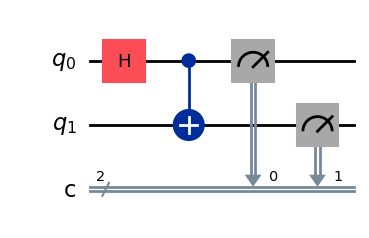

In [7]:
# Crear un circuito con 2 qubits y 2 bits clásicos
qc = QuantumCircuit(2, 2)

# Puerta Hadamard
qc.h(0)

# Puerta CNOT
qc.cx(0, 1)

# Medición
qc.measure([0,1], [0,1])

# Dibujar el circuito
qc.draw("mpl")

In [8]:
simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1000)

result = job.result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)
plt.show()

{'11': 472, '00': 528}


Al ejecutar el circuito 1000 veces se obtuvo el siguiente resultado:

- Estado **00**: 528 mediciones (52.8 %).
- Estado **11**: 472 mediciones (47.2 %).

No se observaron los estados **01** ni **10**, lo cual confirma que el circuito generó correctamente un estado de Bell.

La pequeña diferencia entre el número de mediciones de los estados **00** y **11** se debe a la naturaleza probabilística de la mecánica cuántica y al número finito de ejecuciones (shots). Teóricamente, ambos estados tienen una probabilidad del 50 %, por lo que al incrementar el número de mediciones los resultados tienden a aproximarse a esta distribución.

Estos resultados evidencian que los dos qubits se encuentran entrelazados, ya que las mediciones siempre producen estados correlacionados: ambos qubits son medidos simultáneamente como **00** o **11**, sin obtener combinaciones mixtas como **01** o **10**.

# **Ejercicio 2**

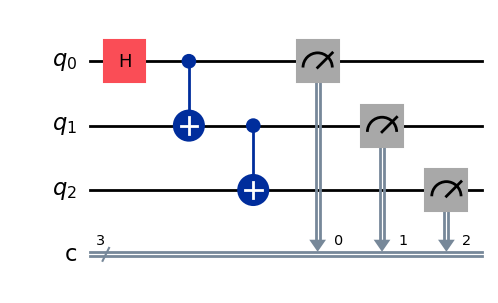

In [11]:
# Agregamos un tercer qubit

qc = QuantumCircuit(3,3)

# Superposición
qc.h(0)

# Primer CNOT
qc.cx(0,1)

# Segundo CNOT
qc.cx(1,2)

# Medición
qc.measure([0,1,2],[0,1,2])

qc.draw("mpl")

In [10]:
simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1000)

result = job.result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)
plt.show()

{'111': 499, '000': 501}


Al ejecutar el circuito 1000 veces se obtuvo el siguiente resultado:

- Estado **000**: 501 mediciones (50.1 %).
- Estado **111**: 499 mediciones (49.9 %).

No se observaron los demás estados posibles (**001**, **010**, **011**, **100**, **101** y **110**), lo que confirma que el circuito generó correctamente un estado GHZ.

La puerta Hadamard aplicada al primer qubit crea una superposición cuántica, mientras que las dos puertas CNOT propagan esta superposición hacia los otros dos qubits, produciendo un estado de entrelazamiento de tres partículas.

Las pequeñas diferencias entre las frecuencias observadas y las probabilidades teóricas del 50 % se deben al carácter probabilístico de las mediciones y al número finito de ejecuciones del circuito (1000 shots).

El resultado obtenido demuestra que los tres qubits se encuentran entrelazados, ya que siempre son medidos simultáneamente en el estado **000** o en el estado **111**, sin observar ninguna combinación intermedia.

# **Ejercicio 3**

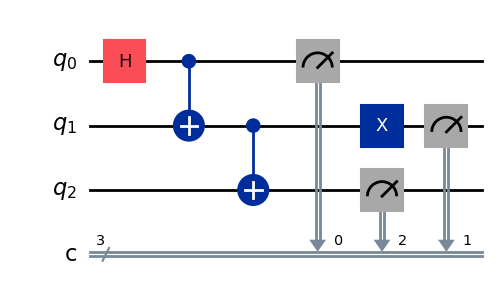

In [12]:
qc = QuantumCircuit(3,3)

qc.h(0)

qc.cx(0,1)

qc.cx(1,2)

# Nueva puerta
qc.x(1)

qc.measure([0,1,2],[0,1,2])

qc.draw("mpl")

In [13]:
simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1000)

result = job.result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)
plt.show()

{'010': 517, '101': 483}


Al ejecutar el circuito 1000 veces se obtuvo el siguiente resultado:

- Estado **010**: 517 mediciones (51.7 %).
- Estado **101**: 483 mediciones (48.3 %).

Estos resultados muestran que la puerta **X** aplicada al segundo qubit modificó correctamente el estado GHZ generado en el ejercicio anterior.

Antes de aplicar la puerta X, el sistema se encontraba en el estado

$$
\frac{|000\rangle+|111\rangle}{\sqrt2}.
$$

La puerta X invierte el estado del segundo qubit, produciendo las transformaciones

$$
|000\rangle \rightarrow |010\rangle,
$$

y

$$
|111\rangle \rightarrow |101\rangle.
$$

Como resultado, el estado final del sistema es

$$
\frac{|010\rangle+|101\rangle}{\sqrt2}.
$$

Las probabilidades obtenidas son cercanas al 50 % para ambos estados, mientras que los demás estados posibles no aparecen en las mediciones. Esto confirma que la puerta X actúa únicamente sobre el segundo qubit, preservando el entrelazamiento del sistema y modificando la superposición de acuerdo con la operación lógica aplicada.